## SETUP

In [44]:
!pip install dezerogym

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from dezerogym.gridworld import GridWorld

## ch07/dezero1.py

In [9]:
# Inner products
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])
# a, b = torch.tensor(a), torch.tensor(b)
c =   torch.matmul(a, b)
print(c)

# Matrix product
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])
c = torch.matmul(a, b)
print(c)

tensor(32)
tensor([[19, 22],
        [43, 50]])


## ch07/dezero2.py

In [ ]:
# 最小値を求める関数の指標となるrosenbrock関数
def rosenbrock(x0, x1):
    y = 100 * (x1 - x0 ** 2) ** 2 + (x0 - 1) ** 2
    return y

x0 = torch.tensor(2., requires_grad=True) # requires_grad=Trueで勾配を計算を指示, 初期値を2に設定
x1 = torch.tensor(2., requires_grad=True) # requires_grad=Trueで勾配を計算を指示, 初期値を2に設定

lr = 0.001
iters = 10000

# 最小値を求める
for i in range(iters):
    y = rosenbrock(x0, x1)

    # 勾配を初期化
    if x0.grad is not None:
        x0.grad.zero_()
    if x1.grad is not None:
        x1.grad.zero_()
    y.backward()

    with torch.no_grad():
        x0 -= lr * x0.grad
        x1 -= lr * x1.grad

print(x0, x1)

tensor(1.0081, requires_grad=True) tensor(1.0162, requires_grad=True)


## ch07/dezero3.py

In [4]:
np.zeros(1)
torch.zeros(1)

tensor([0.])

tensor(41.8980)
tensor(0.2248)
tensor(0.0925)
tensor(0.0888)
tensor(0.0863)
tensor(0.0844)
tensor(0.0829)
tensor(0.0818)
tensor(0.0810)
tensor(0.0803)
====
W = tensor([[2.2864]])
b = tensor([5.3145])


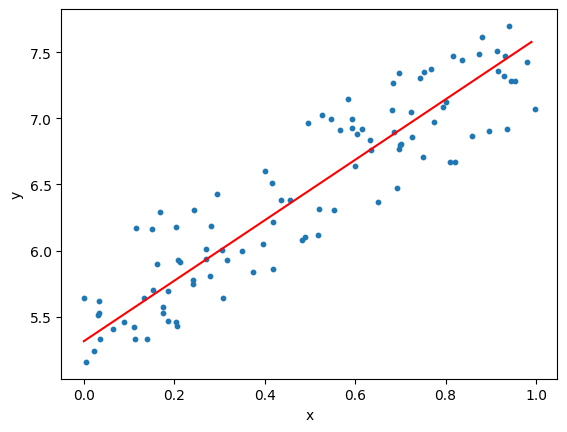

In [ ]:
# トイ・データセット
torch.manual_seed(0)

# x: 0~1の乱数を100個生成し、(100, 1)の形状に変形(reshapeは-1で自動調整)
x = torch.rand(100).reshape(-1, 1)
y = 5 + 2 * x + torch.rand(100).reshape(-1, 1)

# 重みとバイアスの初期化
W = torch.zeros((1, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# 予測関数
def predict(x):
    y = torch.matmul(x, W) + b
    return y

# 平均二乗誤差
def mean_squared_error(x0, x1):
    diff = x0 - x1
    return torch.sum(diff ** 2) / len(diff)

lr = 0.1
iters = 100

for i in range(iters):
    y_pred = predict(x)
    loss = mean_squared_error(y, y_pred)

    # 勾配を初期化
    if W.grad is not None:
        W.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()
    loss.backward()

    with torch.no_grad():
      W -= lr * W.grad
      b -= lr * b.grad

    if i % 10 == 0:
        print(loss.data)

print('====')
print('W =', W.data)
print('b =', b.data)

# Plot
plt.scatter(x.data, y.data, s=10)
plt.xlabel('x')
plt.ylabel('y')
t = torch.arange(0, 1, .01)[:, np.newaxis]
y_pred = predict(t)
plt.plot(t, y_pred.data, color='r')
plt.show()

## ch07/dezero4.py

tensor(0.8830)
tensor(0.2484)
tensor(0.2435)
tensor(0.2337)
tensor(0.2122)
tensor(0.1489)
tensor(0.0844)
tensor(0.1885)
tensor(0.0769)
tensor(0.0767)


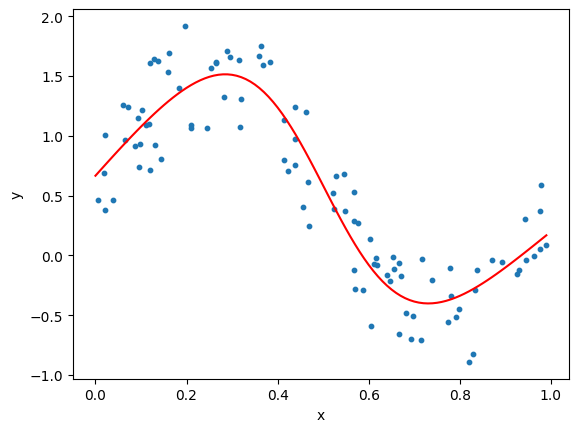

In [6]:
# Dataset
np.random.seed(0)
x = np.random.rand(100, 1)
y = np.sin(2 * np.pi * x) + np.random.rand(100, 1)

# NumPy -> Torch tensor に変換
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)


lr = 0.2
iters = 10000

# nn.Moduleを継承したニューラルネットワークの定義(torchの基本)
class TwoLayerNet(nn.Module):
    def __init__(self, hidden_size, out_size):
        super().__init__()
        self.l1 = nn.Linear(1, hidden_size)
        self.l2 = nn.Linear(hidden_size, out_size)
        self.sigmoid = nn.Sigmoid()

    # 順伝播
    def forward(self, x):
        y = self.sigmoid(self.l1(x))
        y = self.l2(y)
        return y

# 隠れ層のノード数10、出力1のニューラルネットワークを生成
model = TwoLayerNet(10, 1)
# オプティマイザーによる最適化手法の設定(確率的勾配降下法)
sgd = optim.SGD(model.parameters(), lr)
loss_fn = nn.MSELoss()

for i in range(iters):
    y_pred = model(x)
    loss = loss_fn(y, y_pred)

    # 勾配を初期化
    sgd.zero_grad()
    loss.backward()
    sgd.step()

    if i % 1000 == 0:
        print(loss.data)

# Plot
plt.scatter(x, y, s=10)
plt.xlabel('x')
plt.ylabel('y')
t = np.arange(0, 1, .01)[:, np.newaxis]
t_tensor = torch.tensor(t, dtype=torch.float32)
y_pred = model(t_tensor)
plt.plot(t, y_pred.detach().numpy(), color='r')
plt.show()

## ch07/q_learning_nn.py

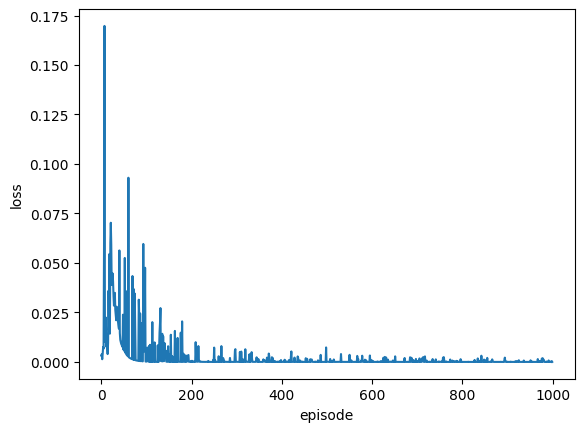

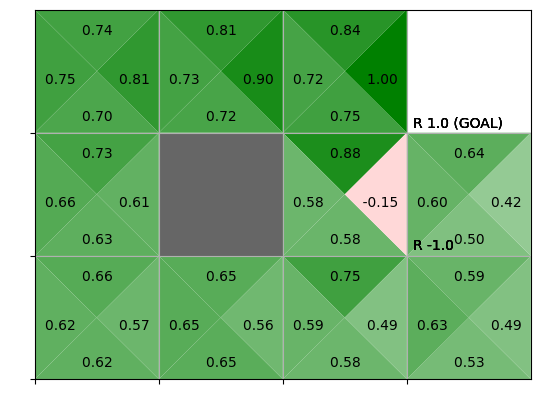

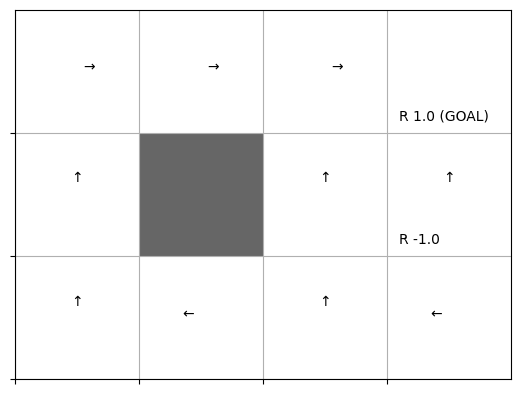

In [ ]:
# グリッドワールドの状態をone-hotベクトルに変換
# グリッドワールドは(縦,横)の配列で状態を表現
# これを3x4=12の1次元one-hotベクトルに変換
def one_hot(state):
    HEIGHT, WIDTH = 3, 4
    vec = np.zeros(HEIGHT * WIDTH, dtype=np.float32)
    y, x = state
    idx = WIDTH * y + x
    vec[idx] = 1.0
    return torch.tensor(vec[np.newaxis, :], dtype=torch.float32) # バッチの次元を追加し、(1, 12)の形状に変換

# Q-network
# 入力は12次元(one-hotベクトル)、出力は4次元(各行動のQ値)
# 隠れ層1層、活性化関数ReLU
class QNet(nn.Module):
    def __init__(self, hidden_size=100, action_size=4):
        super().__init__()
        self.l1 = nn.Linear(12, hidden_size)  # 3 * 4 = 12
        self.l2 = nn.Linear(hidden_size, action_size)
        self.relu = nn.ReLU()

    # 順伝播
    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.l2(x)
        return x


class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.lr = 0.01
        self.epsilon = 0.1
        self.action_size = 4

        # Q-networkを使用
        self.qnet = QNet()
        # オプティマイザ(=最適化アルゴリズム)の設定
        self.optimizer = optim.SGD(self.qnet.parameters(), lr=self.lr)
        # 損失関数の設定(平均二乗誤差)
        self.loss_fn = nn.MSELoss()

    # ε-greedy法で行動を選択
    def get_action(self, state_vec):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            with torch.no_grad():
                qs = self.qnet(state_vec)
                return int(torch.argmax(qs))

    def update(self, state, action, reward, next_state, done):
        qs = self.qnet(state)
        q = qs[0, action]

        with torch.no_grad():
            if done:
                next_q = torch.tensor([0.0])
            else:
                next_q = torch.max(self.qnet(next_state))

        target = self.gamma * next_q + reward

        loss = self.loss_fn(q.unsqueeze(0), target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()


env = GridWorld()
agent = QLearningAgent()

episodes = 1000
loss_history = []

for episode in range(episodes):
    state = env.reset()
    state = one_hot(state)
    total_loss, cnt = 0, 0
    done = False

    while not done:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)
        next_state = one_hot(next_state)

        loss = agent.update(state, action, reward, next_state, done)
        total_loss += loss
        cnt += 1
        state = next_state

    average_loss = total_loss / cnt
    loss_history.append(average_loss)


plt.xlabel('episode')
plt.ylabel('loss')
plt.plot(range(len(loss_history)), loss_history)
plt.show()

# visualize
Q = {}
for state in env.states():
    for action in env.action_space:
        q = agent.qnet(one_hot(state))[:, action]
        Q[state, action] = float(q.data)
env.render_q(Q)